In [662]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, xarray as xr, scipy.io as sio

%matplotlib inline
import matplotlib.pyplot as plt, matplotlib.path as mpath
import cartopy.crs as ccrs
from scipy.interpolate import griddata
from scipy.spatial import cKDTree
plt.rcParams['figure.dpi'] = 110

DATA = Path('/Users/advik/Library/Mobile Documents/com~apple~CloudDocs/Documents/'
            'Documents - MacBook Air/Python/Ice Cores/data/model/ccsm4_last_millenium')
AWS_MAT = Path.home()/'Downloads'/'Mathieu'/'Data'/'dataAWS.mat'

N_POT_RAW, N_EXIST = 5794, 118      # counts as they appear in the files

# Sites to drop before anything else. (-66.44, 162.50) is the Balleny Islands:
# a single isolated cell 378 km from its nearest neighbour, a volcanic group in
# the Southern Ocean rather than part of the ice sheet. Removing it takes the
# maximum nearest-neighbour spacing from 378 km down to 105 km.
EXCLUDE_SITES  = [(-66.44, 162.50)]
EXCLUDE_TOL_KM = 30.0


N_SITES = N_POT_RAW + N_EXIST

ENSEMBLE = 'MRE'      # 'MME' (1001 members) | 'MRE' (160)
VARIABLE = 'Temp'

# Station representativeness error (K^2). Small but nonzero: R=0 asserts a point
# station perfectly measures a ~100 km grid-cell annual mean.
R_AWS_ASSIM = 0.0

# Ice-core R = k/A. k estimated from 42 replicate core pairs: sigma^2 = 2.202
# per mil^2 measured at A = 88.2 mm/yr.
D18O_TO_T, SIGMA2_D18O, A_CALIB = 2.0, 2.202, 88.2

# Which metric to constrain.
#   'computed' -> cos(lat)-weighted spatial mean of the estimates (Cell 4).
#                 Exact by construction; you control the mask and weighting.
#   'file'     -> {ENSEMBLE}{VARIABLE}.mat as shipped. NOTE: this is NOT a
#                 spatial average of the estimates -- it sits 6.4 K colder than
#                 the land-site mean, correlates 0.897 with it, and no single
#                 CCSM4 cell exceeds 0.892. It IS member-aligned, so results
#                 are internally valid, but its definition is unrecoverable.
METRIC_SOURCE = 'computed'      # 'computed' | 'file'

METRIC_GROUNDED_ONLY     = True    # metric over grounded ice only ('computed')
METRIC_AREA_WEIGHTED     = True    # cos(lat) weighting ('computed')
CANDIDATES_GROUNDED_ONLY = False   # you can still drill anywhere




print('DATA ok:', DATA.exists(), '| AWS ok:', AWS_MAT.exists())


DATA ok: True | AWS ok: True


In [663]:
def read_numbers(p):
    o = []
    for t in Path(p).read_text().split():
        try: o.append(float(t))
        except ValueError: pass
    return np.asarray(o, float)

N_BLOCKS, DEBLOCK_MRE = 4, True

def deblock(X, nb=N_BLOCKS):
    """Remove each reanalysis's own mean. The MRE temperature METRIC carries a
    ~40 K ERA5 block offset that the ESTIMATES do not, which is why raw MRE J
    correlates only 0.20 with the spatial mean of its own Ye -- and 0.95 once
    both are deblocked. Never applied to MME."""
    X = np.asarray(X, float)
    if X.shape[-1] % nb:
        raise ValueError(X.shape)
    return np.concatenate([b - b.mean(-1, keepdims=True)
                           for b in np.split(X, nb, axis=-1)], axis=-1)

def load_Ye(variable=None, ensemble=None):
    variable = variable or VARIABLE; ensemble = ensemble or ENSEMBLE
    k = f'{variable}{ensemble}Ye'
    Ye = np.asarray(sio.loadmat(DATA / f'{k}.mat')[k], float)
    assert Ye.shape[0] == N_SITES, Ye.shape
    return deblock(Ye) if (ensemble == 'MRE' and DEBLOCK_MRE) else Ye

def load_file_metric(variable=None, ensemble=None):
    """The metric shipped in {ENSEMBLE}{VARIABLE}.mat -- kept for comparison
    only. It is NOT a spatial average of the estimates (see Cell 4)."""
    variable = variable or VARIABLE; ensemble = ensemble or ENSEMBLE
    k = f'{ensemble}{variable}'
    J = np.asarray(sio.loadmat(DATA / f'{k}.mat')[k], float).ravel()
    return deblock(J) if (ensemble == 'MRE' and DEBLOCK_MRE) else J

Ye = load_Ye()
nM = Ye.shape[1]; unbias = 1/(nM - 1)
print(f'{ENSEMBLE} {VARIABLE}: Ye {Ye.shape}  '
      f'deblock={"on" if ENSEMBLE=="MRE" and DEBLOCK_MRE else "off"}')


MRE Temp: Ye (5912, 160)  deblock=on


In [664]:
ccsm_lat = np.linspace(-90, 90, 192)
ccsm_lon = np.arange(288) * 1.25

def build_site_coords():
    era = xr.open_dataset(DATA / 'data.nc')
    t2m = era[list(era.data_vars)[0]].values
    tm = np.roll(t2m, 1800, axis=2)
    li = pd.read_csv(DATA / 'latInd.csv').values.ravel().astype(int)
    tr = np.zeros((32, 3600))
    for i, it in enumerate(li):
        tr[i, :] = tm[0, it]
    sec = np.zeros((32, 7200))
    for i in range(32):
        sec[i, :7198] = np.dstack((tr[i, :-1],
                                   tr[i, :-1] + np.diff(tr[i])/2.0)).ravel()
    rg = sec[:, ::25]
    la, lo = [], []
    for i in range(32):
        for j in range(288):
            if rg[i, j] > 0:
                la.append(ccsm_lat[i]); lo.append(ccsm_lon[j])
    return np.array(la), np.array(lo)

site_lat, site_lon = build_site_coords()
site_lat_raw, site_lon_raw = site_lat, site_lon
assert site_lat_raw.size == N_POT_RAW

drop = np.zeros(N_POT_RAW, bool)
for la, lo in EXCLUDE_SITES:
    drop |= haversine_km(la, np.mod(lo, 360.), site_lat_raw, site_lon_raw) < EXCLUDE_TOL_KM
keep_pot = ~drop

print(f'excluding {drop.sum()} site(s): ' + ', '.join(
    f'{k} ({site_lat_raw[k]:.2f}, {site_lon_raw[k]:.2f})' for k in np.flatnonzero(drop)))

site_lat, site_lon = site_lat_raw[keep_pot], site_lon_raw[keep_pot]
Ye = np.concatenate([Ye[:N_POT_RAW][keep_pot], Ye[N_POT_RAW:]])   # keep the 118 existing
N_POTENTIAL = int(keep_pot.sum())
N_SITES     = N_POTENTIAL + N_EXIST
print(f'N_POTENTIAL {N_POT_RAW} -> {N_POTENTIAL};  Ye now {Ye.shape}')

# grounding-line mask on the reduced set
gl = pd.read_csv(DATA / 'IceShelfMask.csv')['Mask'].values.astype(float)
is_shelf = site_lat > gl[(np.round(site_lon/1.25).astype(int)) % 288]
grounded = ~is_shelf
print(f'{N_POTENTIAL} sites: {is_shelf.sum()} shelf, {grounded.sum()} grounded')

assert site_lat.size == N_POTENTIAL

# IceShelfMask.csv is the MOA grounding-line latitude at each of 288 longitudes.
# A site north of it is floating. Verified: 550 shelf / 5244 grounded, matching
# TempMMEMasked.mat's row count exactly.
gl = pd.read_csv(DATA / 'IceShelfMask.csv')['Mask'].values.astype(float)
is_shelf = site_lat > gl[(np.round(site_lon/1.25).astype(int)) % 288]
grounded = ~is_shelf

print(f'{N_POTENTIAL} sites: {is_shelf.sum()} shelf, {grounded.sum()} grounded')
print(f'  cross-check TempMMEMasked.mat rows: '
      f'{sio.loadmat(DATA/"TempMMEMasked.mat")["Ye"].shape[0]}')


excluding 1 site(s): 5777 (-66.44, 162.50)
N_POTENTIAL 5794 -> 5793;  Ye now (5911, 160)
5793 sites: 549 shelf, 5244 grounded
5793 sites: 549 shelf, 5244 grounded
  cross-check TempMMEMasked.mat rows: 5244


In [665]:
def build_metric(Ye, mask=None, weights=None):
    """cos(lat)-weighted spatial mean of the estimates over `mask`.

    Verified against exact spherical-band cell areas: identical to 4 decimals
    (235.693 vs 235.686 K, corr 1.00000), so cos(lat) is the correct weight on
    this regular lat-lon grid. Unweighted averaging is NOT equivalent
    (corr 0.961) -- the 288 sites at exactly -90 deg are all the same physical
    point and would otherwise carry 5% of the total weight.
    """
    Y = Ye[:N_POTENTIAL]
    m = np.ones(N_POTENTIAL, bool) if mask is None else np.asarray(mask, bool)
    if weights is None:
        w = np.cos(np.deg2rad(site_lat)) if METRIC_AREA_WEIGHTED \
            else np.ones(N_POTENTIAL)
    else:
        w = np.asarray(weights, float)
    w = w[m]
    return (Y[m] * w[:, None]).sum(0) / w.sum()

metric_mask = grounded if METRIC_GROUNDED_ONLY else np.ones(N_POTENTIAL, bool)
J_computed  = build_metric(Ye, mask=metric_mask)
J_file      = load_file_metric()

if METRIC_SOURCE == 'computed':
    J = J_computed
    desc = (f'computed: {"cos(lat)-weighted" if METRIC_AREA_WEIGHTED else "unweighted"} '
            f'mean over {metric_mask.sum()} '
            f'{"grounded" if METRIC_GROUNDED_ONLY else "all"} sites')
elif METRIC_SOURCE == 'file':
    J = J_file
    desc = f'file: {ENSEMBLE}{VARIABLE}.mat as shipped'
else:
    raise ValueError(METRIC_SOURCE)

J0var = unbias * ((J - J.mean())**2).sum()
print(f'METRIC_SOURCE = {METRIC_SOURCE!r}  ->  {desc}')
print(f'  mean {J.mean():.3f} K   sd {J.std(ddof=1):.4f} K   variance {J0var:.5f}')
print()
print(f'  computed : mean {J_computed.mean():8.3f}  sd {J_computed.std(ddof=1):.4f}')
print(f'  file     : mean {J_file.mean():8.3f}  sd {J_file.std(ddof=1):.4f}')
print(f'  corr(computed, file) = {np.corrcoef(J_computed, J_file)[0,1]:.4f}')
if METRIC_SOURCE == 'file':
    print('  WARNING: the file metric is not a spatial average of the estimates.')


METRIC_SOURCE = 'computed'  ->  computed: cos(lat)-weighted mean over 5244 grounded sites
  mean 0.000 K   sd 0.5642 K   variance 0.31829

  computed : mean    0.000  sd 0.5642
  file     : mean   -0.000  sd 0.6641
  corr(computed, file) = 0.9049


In [666]:
TINY = 1e-12

def variance_reduction(Jdev, Ydev, Rvar, unb):
    den = unb * (Ydev**2).sum(1) + Rvar
    num = (unb * (Ydev @ Jdev))**2
    return np.where(den > TINY, num / np.where(den > TINY, den, 1.0), 0.0)

def adjusted_gain(Kn, Kd, Rb):
    ks = np.sqrt(Kd); return Kn / ks / (ks + np.sqrt(Rb))

def haversine_km(a, b, c, d, Rk=6371.0088):
    a, b, c, d = map(np.radians, (a, b, c, d))
    h = np.sin((c-a)/2)**2 + np.cos(a)*np.cos(c)*np.sin((d-b)/2)**2
    return 2*Rk*np.arcsin(np.sqrt(np.clip(h, 0, 1)))

class OptimalSensor:
    """DASH @optimalSensor (Comboul et al. 2015)."""
    def __init__(self, J, Ye, R):
        J = np.asarray(J, float).ravel()
        self.nM = J.size; self.unbias = 1/(self.nM - 1)
        self.Jdev = J - J.mean()
        Ye = np.asarray(Ye, float)
        self.Ydev = Ye - Ye.mean(1, keepdims=True)
        self.R = (np.full(Ye.shape[0], float(R)) if np.isscalar(R)
                  else np.asarray(R, float).ravel().copy())
        self.J0var = self.metric_variance()

    def metric_variance(self):
        return self.unbias * (self.Jdev**2).sum()

    def evaluate(self):
        return variance_reduction(self.Jdev, self.Ydev, self.R, self.unbias)

    def assimilate(self, i, Rval=None):
        Yb = self.Ydev[i].copy()
        Rb = self.R[i] if Rval is None else Rval
        Yv = self.unbias * (Yb**2).sum()
        if Yv + Rb <= TINY:
            self.Ydev[i] = np.nan
            return self.metric_variance()
        Ka = adjusted_gain(self.unbias * (self.Jdev @ Yb), Yv + Rb, Rb)
        self.Jdev = self.Jdev - Ka*Yb
        self.Ydev = self.Ydev - Ka*Yb
        self.Ydev[i] = np.nan
        return self.metric_variance()

    def run(self, N, exclude=None, min_sep_km=0.0, verbose=True):
        st, vs = [], []
        banned = np.zeros(self.Ydev.shape[0], bool)
        if exclude is not None:
            banned |= np.asarray(exclude, bool)
        for s_ in range(N):
            dv = self.evaluate()
            dv = np.where(np.isfinite(dv), dv, -np.inf); dv[banned] = -np.inf
            for k in st: dv[k] = -np.inf
            b = int(np.argmax(dv)); v = self.assimilate(b)
            if min_sep_km > 0:
                banned |= haversine_km(site_lat[b], site_lon[b],
                                       site_lat, site_lon) < min_sep_km
            st.append(b); vs.append(v)
            if verbose:
                print(f'  {s_+1:3d} site {b:5d} ({site_lat[b]:7.2f}, {site_lon[b]:7.2f})  '
                      f'cumulative {100*(1-v/self.J0var):5.1f}%')
        return np.array(st), np.array(vs)

print('OptimalSensor defined')


OptimalSensor defined


In [667]:
# Uses the ORIGINAL metric and RSheet, read directly -- this validates the
# ALGORITHM and must pass regardless of the metric or R choices above.
_ky, _kj = f'{VARIABLE}{ENSEMBLE}Ye', f'{ENSEMBLE}{VARIABLE}'
Ye_raw = np.asarray(sio.loadmat(DATA / f'{_ky}.mat')[_ky], float)
J_raw  = np.asarray(sio.loadmat(DATA / f'{_kj}.mat')[_kj], float).ravel()
R_ref  = read_numbers(DATA / 'RSheet.csv')[:N_POTENTIAL]
tgt    = read_numbers(DATA / f'BS_{ENSEMBLE}_{VARIABLE.lower()}_accumR.csv')

dv_chk = OptimalSensor(J_raw, Ye_raw[:N_POT_RAW],
                       read_numbers(DATA / 'RSheet.csv')[:N_POT_RAW]).evaluate()

corr = np.corrcoef(dv_chk, tgt)[0, 1]
rel  = np.max(np.abs(dv_chk - tgt) / np.maximum(np.abs(tgt), 1e-30))
print(f'algorithm check: 1 - corr {1-corr:.3e}   max rel err {rel:.3e}  '
      f'(CSV precision floor ~5e-5)')
assert corr > 1 - 1e-8 and rel < 1e-3, 'does not match MATLAB'
print('matches the MATLAB output to the precision of the reference file')


algorithm check: 1 - corr 1.289e-10   max rel err 4.894e-05  (CSV precision floor ~5e-5)
matches the MATLAB output to the precision of the reference file


In [668]:
_aws = sio.loadmat(AWS_MAT, squeeze_me=True, struct_as_record=False)['dataAWS']
rows = []
for n_ in _aws._fieldnames:
    r = getattr(_aws, n_)
    la, lo = float(r.lat), np.mod(float(r.lon), 360.0)
    d = haversine_km(la, lo, site_lat, site_lon); k = int(np.argmin(d))
    rows.append(dict(station=n_, lat=la, lon=lo, site=k, km=d[k],
                     shelf=bool(is_shelf[k])))
aws_map = pd.DataFrame(rows)
AWS_SITES = sorted(set(aws_map.site))
print(f'{len(aws_map)} stations -> {len(AWS_SITES)} cells, '
      f'max offset {aws_map.km.max():.0f} km, {aws_map.shelf.sum()} on shelf cells')
aws_map.round(1)


17 stations -> 16 cells, max offset 125 km, 10 on shelf cells


,station,lat,lon,site,km,shelf
0,FaradayVernadsky,-65.1,295.8,5784,43.9,True
1,Rothera,-67.3,291.9,5743,25.3,True
2,Byrd,-80.0,240.7,3361,43.3,False
3,Marambio,-64.2,303.4,5791,124.9,True
4,Mawson,-67.6,62.9,5615,82.3,False
5,Davis,-68.6,78.0,5622,43.3,False
6,McMurdo,-77.9,166.7,3876,25.2,True
7,DDU,-66.7,140.0,5737,75.9,False
8,Bellingshausen,-62.1,301.4,5792,95.4,True
9,Neumayer,-70.4,351.8,5350,86.3,True


In [669]:
accum_rate = sio.loadmat(DATA / 'AccumMMEYe.mat')['AccumMMEYe'].mean(1)[:N_POT_RAW][keep_pot]
_Rs = read_numbers(DATA / 'RSheet.csv')[:N_POT_RAW][keep_pot]
assert np.allclose(_Rs * accum_rate, 1e4, rtol=1e-6), 'RSheet is not 10000/A'

K_TEMP = D18O_TO_T**2 * SIGMA2_D18O * A_CALIB
R_ICE_CORE = K_TEMP / accum_rate
print(f'k_temp = {K_TEMP:.0f}  ->  R median {np.median(R_ICE_CORE):.2f} K^2, '
      f'range {R_ICE_CORE.min():.2f} .. {R_ICE_CORE.max():.1f}')


k_temp = 777  ->  R median 9.70 K^2, range 0.74 .. 37.7


In [670]:
rng = np.random.default_rng(0)

def constrain(idx, Rval):
    o = OptimalSensor(J, Ye[:N_POTENTIAL], 0.0)
    for i in idx:
        o.assimilate(int(i), Rval=Rval)
    return 100 * (1 - o.metric_variance()/o.J0var)

real = constrain(AWS_SITES, R_AWS_ASSIM)
rand = [constrain(rng.choice(N_POTENTIAL, len(AWS_SITES), replace=False), R_AWS_ASSIM)
        for _ in range(20)]
print(f'DOF: {len(AWS_SITES)} obs / {nM-1} = {100*len(AWS_SITES)/(nM-1):.1f}% of budget')
print(f'AWS network constrains {real:.1f}%  |  {len(AWS_SITES)} random: '
      f'{np.mean(rand):.1f}% +/- {np.std(rand):.1f}%  |  gap {real-np.mean(rand):+.1f}%')


DOF: 16 obs / 159 = 10.1% of budget
AWS network constrains 94.4%  |  16 random: 93.1% +/- 4.2%  |  gap +1.3%


In [671]:
excl = is_shelf if CANDIDATES_GROUNDED_ONLY else None

def experiment(candidate_R, n_top=10, min_sep_km=0.0):
    o = OptimalSensor(J, Ye[:N_POTENTIAL], candidate_R)
    J0 = o.J0var
    for i in AWS_SITES:
        o.assimilate(int(i), Rval=R_AWS_ASSIM)
    v0 = o.metric_variance()
    dv = o.evaluate()
    st, vr = o.run(n_top, exclude=excl, min_sep_km=min_sep_km, verbose=False)
    return J0, v0, np.where(np.isfinite(dv), dv, np.nan), st, vr

res = {}
for lbl, cand in [('ICE CORE', R_ICE_CORE), ('AWS', R_AWS_ASSIM)]:
    res[lbl] = experiment(cand)
    J0, v0, dv, st, vr = res[lbl]
    print(f'\n=== new {lbl} ===   AWS network leaves {v0:.5f} of {J0:.5f} '
          f'({100*(1-v0/J0):.1f}% constrained)')
    print(pd.DataFrame({
        'rank': range(1, 11), 'site': st,
        'lat': site_lat[st], 'lon': site_lon[st],
        'accum': accum_rate[st], 'shelf': is_shelf[st],
        'R': (R_ICE_CORE[st] if lbl == 'ICE CORE' else np.full(10, R_AWS_ASSIM)),
        'pct_remaining': 100*(1 - vr/v0),
    }).set_index('rank').round(2).to_string())



=== new ICE CORE ===   AWS network leaves 0.01773 of 0.31829 (94.4% constrained)
      site    lat     lon   accum  shelf     R  pct_remaining
rank                                                         
1     4634 -74.92  281.25  469.15   True  1.66           5.17
2     4378 -75.86  227.50  732.00  False  1.06           9.26
3     4635 -74.92  282.50  446.28  False  1.74          11.82
4     2153 -83.40  171.25  146.71   True  5.30          13.96
5     4379 -75.86  228.75  722.06  False  1.08          15.75
6     3299 -79.63  163.75  196.44  False  3.95          17.30
7     3944 -77.75  276.25  379.57  False  2.05          18.62
8     2152 -83.40  170.00  160.81  False  4.83          19.85
9     3711 -78.69  318.75  188.65   True  4.12          21.04
10    5192 -72.09  346.25  452.20   True  1.72          22.33

=== new AWS ===   AWS network leaves 0.01773 of 0.31829 (94.4% constrained)
      site    lat     lon   accum  shelf    R  pct_remaining
rank                                

In [672]:
_s = pd.read_csv(DATA / 'Sites.csv', header=None).values.astype(float)
_s[_s[:, 1] == 161.64, 1] = -161.64
exist_lat, exist_lon = _s[:, 0], _s[:, 1]

def interp_field(v, ngrid=100, thr=1.0):
    lg = np.linspace(site_lon.min(), site_lon.max(), ngrid)
    ag = np.linspace(site_lat.min(), site_lat.max(), ngrid)
    lm, am = np.meshgrid(lg, ag)
    d, _ = cKDTree(np.column_stack((site_lon, site_lat))).query(
        np.column_stack((lm.ravel(), am.ravel())))
    g = griddata((site_lon, site_lat), np.asarray(v, float), (lm, am), method='linear')
    g[d.reshape(lm.shape) > thr] = np.nan
    return lm, am, g

def plot_map(frac, title, top_idx=None, top_size=220, show_aws=True,
             ax=None, fig=None, figsize=(12, 11)):
    lm, am, g = interp_field(frac)
    if ax is None:
        fig = plt.figure(figsize=figsize)
        ax = plt.axes(projection=ccrs.SouthPolarStereo())
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree()); ax.gridlines()
    pm = ax.pcolormesh(lm, am, g, zorder=0, transform=ccrs.PlateCarree(),
                       cmap=plt.cm.Greens, vmin=0, vmax=1)
    if show_aws:
        ax.scatter(aws_map.lon, aws_map.lat, marker='^', s=70, c='red',
                   edgecolors='k', lw=.7, zorder=2, transform=ccrs.PlateCarree())
    ax.coastlines()
    if top_idx is not None:
        n = len(top_idx); rk = np.arange(1, n+1); o = np.arange(n)[::-1]
        ax.scatter(site_lon[top_idx][o], site_lat[top_idx][o], c=rk[o], s=top_size,
                   lw=1.5, edgecolors='k', cmap=plt.cm.cool_r, vmin=.5, vmax=n+.5,
                   zorder=3, transform=ccrs.PlateCarree())
    ax.set_title(title, fontsize=12)
    return fig, ax, pm


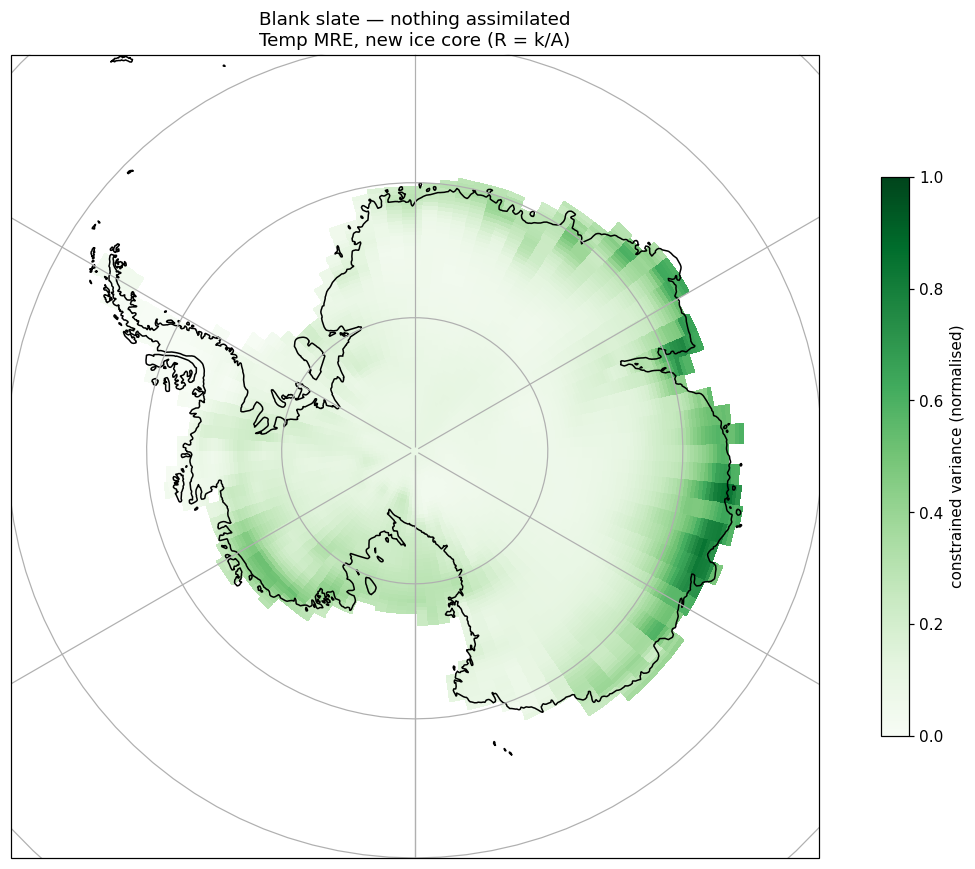

metric variance 0.31829
best site 5710 (-67.38, 106.25)  accum 503 mm/yr  R 1.54 K^2
  constrains 22.83% of the metric variance


In [673]:
# Nothing assimilated: what a new ice core would constrain with no network.
# Swap R_ICE_CORE for R_AWS_ASSIM to ask the same question for a new station.
os_blank = OptimalSensor(J, Ye[:N_POTENTIAL], R_ICE_CORE)
dv_blank = os_blank.evaluate()

fig, ax, pm = plot_map(dv_blank / np.nanmax(dv_blank),
                       f'Blank slate — nothing assimilated\n'
                       f'{VARIABLE} {ENSEMBLE}, new ice core (R = k/A)',
                       show_aws=False)
cb = fig.colorbar(pm, ax=ax, shrink=.6, pad=.06)
cb.set_label('constrained variance (normalised)')
plt.show()

k = int(np.nanargmax(dv_blank))
print(f'metric variance {os_blank.J0var:.5f}')
print(f'best site {k} ({site_lat[k]:.2f}, {site_lon[k]:.2f})  '
      f'accum {accum_rate[k]:.0f} mm/yr  R {R_ICE_CORE[k]:.2f} K^2')
print(f'  constrains {100*dv_blank.max()/os_blank.J0var:.2f}% of the metric variance')


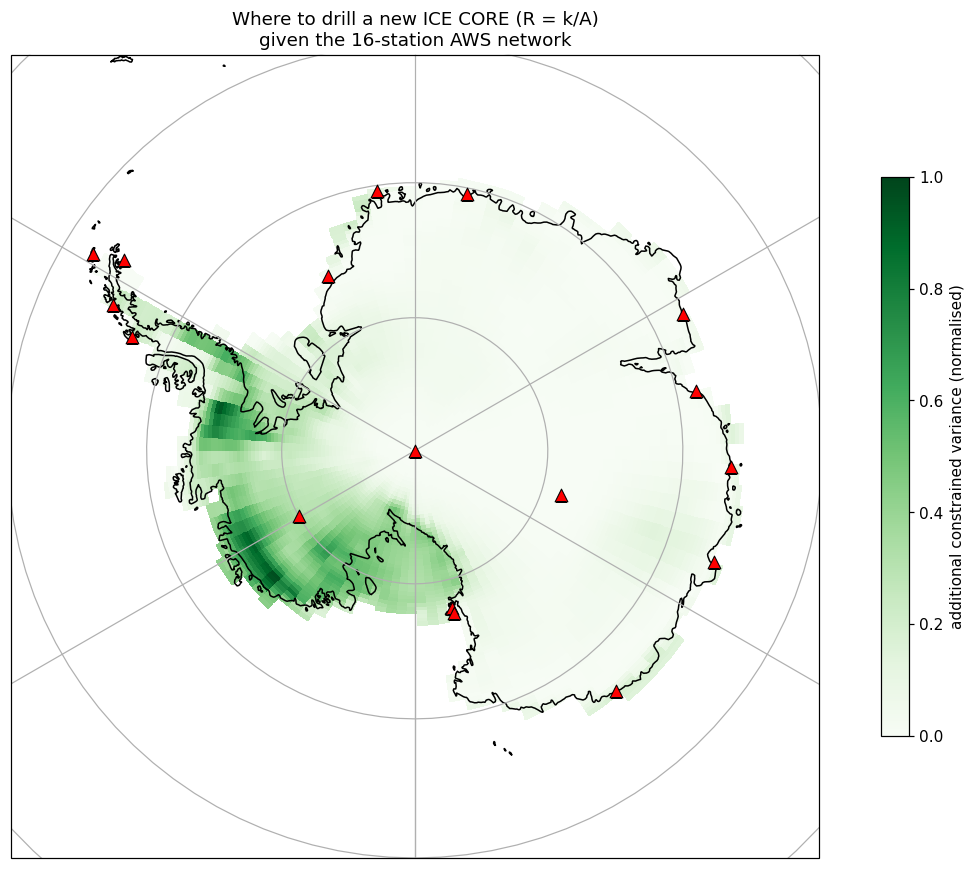

AWS network leaves 0.01773 of 0.31829 (94.4% constrained)
best site 4634 (-74.92, 281.25)  accum 469  R 1.66  adds 5.17% of what remains


In [674]:
J0, v0, dv_core, st_core, vr_core = res['ICE CORE']

fig, ax, pm = plot_map(dv_core / np.nanmax(dv_core),
                       f'Where to drill a new ICE CORE (R = k/A)\n'
                       f'given the {len(AWS_SITES)}-station AWS network')
cb = fig.colorbar(pm, ax=ax, shrink=.6, pad=.06)
cb.set_label('additional constrained variance (normalised)')
plt.show()

k = int(np.nanargmax(dv_core))
print(f'AWS network leaves {v0:.5f} of {J0:.5f} ({100*(1-v0/J0):.1f}% constrained)')
print(f'best site {k} ({site_lat[k]:.2f}, {site_lon[k]:.2f})  '
      f'accum {accum_rate[k]:.0f}  R {R_ICE_CORE[k]:.2f}  '
      f'adds {100*np.nanmax(dv_core)/v0:.2f}% of what remains')


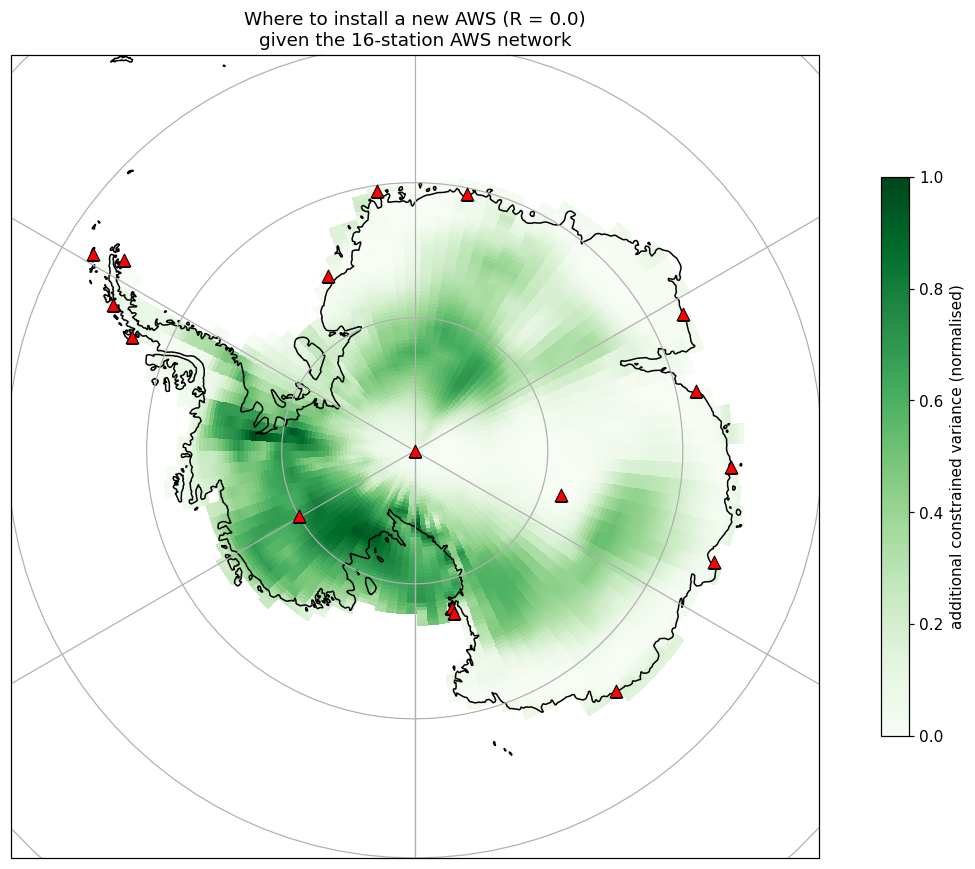

best site 3943 (-77.75, 275.00)  accum 375  adds 19.05% of what remains


In [675]:
J0, v0, dv_aws, st_aws, vr_aws = res['AWS']

fig, ax, pm = plot_map(dv_aws / np.nanmax(dv_aws),
                       f'Where to install a new AWS (R = {R_AWS_ASSIM})\n'
                       f'given the {len(AWS_SITES)}-station AWS network')
cb = fig.colorbar(pm, ax=ax, shrink=.6, pad=.06)
cb.set_label('additional constrained variance (normalised)')
plt.show()

k = int(np.nanargmax(dv_aws))
print(f'best site {k} ({site_lat[k]:.2f}, {site_lon[k]:.2f})  '
      f'accum {accum_rate[k]:.0f}  adds {100*np.nanmax(dv_aws)/v0:.2f}% of what remains')


AIS metric variance 0.31829; AWS network leaves 0.01773 (94.4% constrained)
      site    lat     lon   accum     R  alone_pct  cum_pct_remaining
rank                                                                 
1     4634 -74.92  281.25  469.15  1.66       5.17               5.17
2     4378 -75.86  227.50  732.00  1.06       5.12               9.26
3     2153 -83.40  171.25  146.71  5.30       2.88              11.58
4     4385 -75.86  236.25  617.77  1.26       4.75              13.65
5     3944 -77.75  276.25  379.57  2.05       3.36              15.43


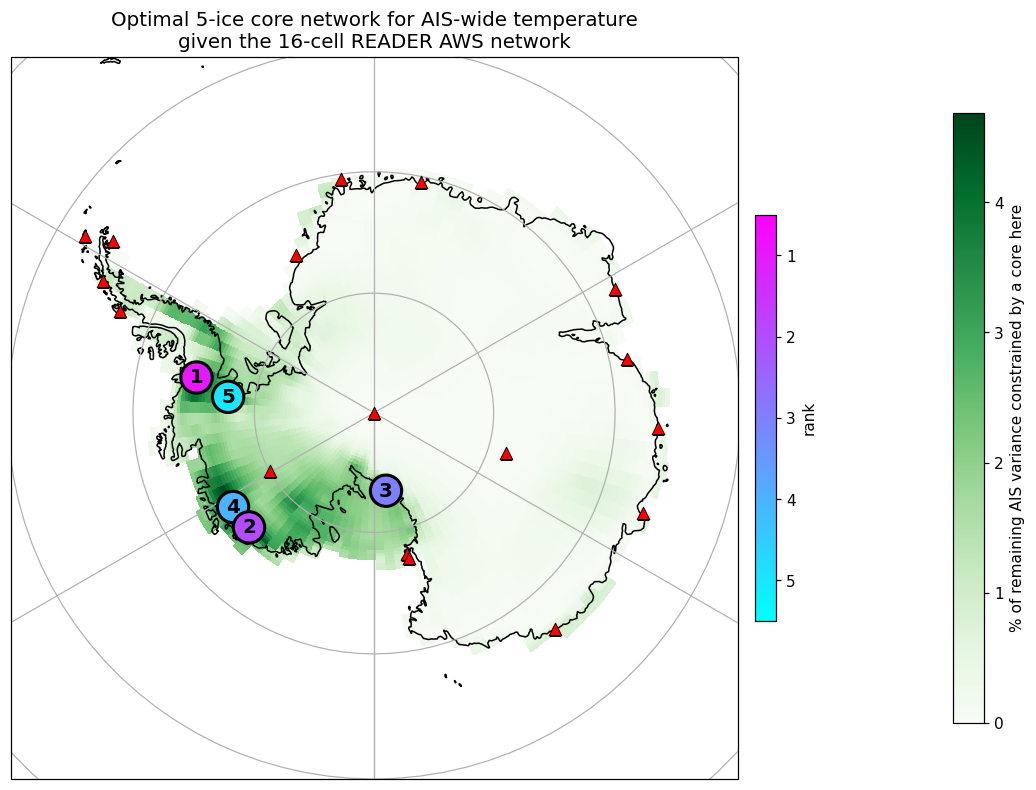

In [676]:
N_NEW      = 5
MIN_SEP_KM = 200.0     # 0 reproduces the raw algorithm, but sites 2 and 5 then
                       # land in adjacent cells (~50 km apart). 200 km costs only
                       # 13.78 -> 13.60% cumulative and gives distinct sites.

# --- run: new ice core (R = k/A), given the assimilated AWS network ---
o = OptimalSensor(J, Ye[:N_POTENTIAL], R_ICE_CORE)
J0 = o.J0var
for i in AWS_SITES:
    o.assimilate(int(i), Rval=R_AWS_ASSIM)
v0 = o.metric_variance()
dv = np.where(np.isfinite(o.evaluate()), o.evaluate(), np.nan)
pct = 100 * dv / v0                       # % of REMAINING variance, per site alone

o2 = OptimalSensor(J, Ye[:N_POTENTIAL], R_ICE_CORE)
for i in AWS_SITES:
    o2.assimilate(int(i), Rval=R_AWS_ASSIM)
st, vr = o2.run(N_NEW, min_sep_km=MIN_SEP_KM, verbose=False)

print(f'AIS metric variance {J0:.5f}; AWS network leaves {v0:.5f} '
      f'({100*(1-v0/J0):.1f}% constrained)')
print(pd.DataFrame({'rank': range(1, N_NEW+1), 'site': st,
                    'lat': site_lat[st], 'lon': site_lon[st],
                    'accum': accum_rate[st], 'R': R_ICE_CORE[st],
                    'alone_pct': pct[st],
                    'cum_pct_remaining': 100*(1 - vr/v0)}).set_index('rank')
      .round(2).to_string())

# --- map ---
SP, PL = ccrs.SouthPolarStereo(), ccrs.PlateCarree()
fig = plt.figure(figsize=(13, 12))
ax = plt.axes(projection=SP)
ax.set_extent([-180, 180, -90, -60], PL); ax.gridlines()

lm, am, g = interp_field(pct)
pm = ax.pcolormesh(lm, am, g, transform=PL, cmap=plt.cm.Greens,
                   vmin=0, vmax=np.nanpercentile(pct, 99.8), zorder=0)

ax.scatter(aws_map.lon, aws_map.lat, marker='^', s=70, c='red',
           edgecolors='k', lw=.6, transform=PL, zorder=2)

rk = np.arange(1, N_NEW+1); order = np.arange(N_NEW)[::-1]   # rank 1 drawn last
sc = ax.scatter(site_lon[st][order], site_lat[st][order], c=rk[order], s=420,
                lw=2, edgecolors='k', cmap=plt.cm.cool_r,
                vmin=.5, vmax=N_NEW+.5, transform=PL, zorder=4)
for r_, k in enumerate(st, 1):
    ax.annotate(str(r_), (site_lon[k], site_lat[k]),
                xycoords=PL._as_mpl_transform(ax), ha='center', va='center',
                fontsize=13, fontweight='bold', zorder=5)
ax.coastlines()

cb = fig.colorbar(pm, ax=ax, shrink=.6, pad=.06)
cb.set_label('% of remaining AIS variance constrained by a core here')
cbr = fig.colorbar(sc, ax=ax, shrink=.4, pad=.02, ticks=rk)
cbr.set_label('rank'); cbr.ax.invert_yaxis()
ax.set_title(f'Optimal {N_NEW}-ice core network for AIS-wide temperature\n'
             f'given the {len(AWS_SITES)}-cell READER AWS network', fontsize=13)
plt.show()


AIS metric variance 0.31829; AWS network leaves 0.01773 (94.4% constrained)
      site    lat     lon   accum  alone_pct  cum_pct_remaining
rank                                                           
1     3943 -77.75  275.00  374.70      19.05              19.05
2     2045 -83.40   36.25   40.27      13.55              38.63
3     4555 -74.92  116.25   31.06      10.04              52.50
4     1872 -84.35  180.00  148.97      17.23              65.99
5     2867 -81.52  343.75  107.80       8.18              69.95


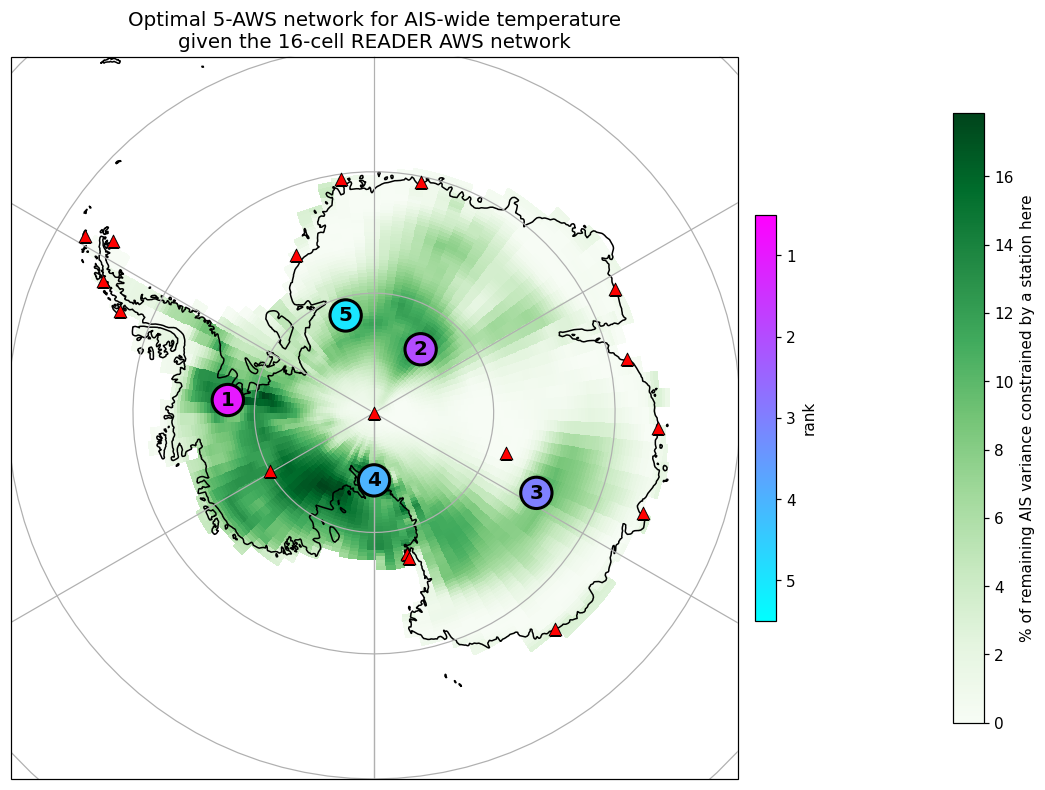

In [677]:
N_NEW      = 5
MIN_SEP_KM = 200.0     # for the AWS case this changes nothing -- the top 5 are
                       # already >200 km apart, unlike the ice-core case.

# --- run: new AWS station (R = R_AWS_ASSIM), given the assimilated network ---
o = OptimalSensor(J, Ye[:N_POTENTIAL], R_AWS_ASSIM)
J0 = o.J0var
for i in AWS_SITES:
    o.assimilate(int(i), Rval=R_AWS_ASSIM)
v0 = o.metric_variance()
dv = np.where(np.isfinite(o.evaluate()), o.evaluate(), np.nan)
pct = 100 * dv / v0                       # % of REMAINING variance, per site alone

o2 = OptimalSensor(J, Ye[:N_POTENTIAL], R_AWS_ASSIM)
for i in AWS_SITES:
    o2.assimilate(int(i), Rval=R_AWS_ASSIM)
st, vr = o2.run(N_NEW, min_sep_km=MIN_SEP_KM, verbose=False)

print(f'AIS metric variance {J0:.5f}; AWS network leaves {v0:.5f} '
      f'({100*(1-v0/J0):.1f}% constrained)')
print(pd.DataFrame({'rank': range(1, N_NEW+1), 'site': st,
                    'lat': site_lat[st], 'lon': site_lon[st],
                    'accum': accum_rate[st],
                    'alone_pct': pct[st],
                    'cum_pct_remaining': 100*(1 - vr/v0)}).set_index('rank')
      .round(2).to_string())

# --- map ---
SP, PL = ccrs.SouthPolarStereo(), ccrs.PlateCarree()
fig = plt.figure(figsize=(13, 12))
ax = plt.axes(projection=SP)
ax.set_extent([-180, 180, -90, -60], PL); ax.gridlines()

lm, am, g = interp_field(pct)
pm = ax.pcolormesh(lm, am, g, transform=PL, cmap=plt.cm.Greens,
                   vmin=0, vmax=np.nanpercentile(pct, 99.8), zorder=0)

ax.scatter(aws_map.lon, aws_map.lat, marker='^', s=70, c='red',
           edgecolors='k', lw=.6, transform=PL, zorder=2)

rk = np.arange(1, N_NEW+1); order = np.arange(N_NEW)[::-1]   # rank 1 drawn last
sc = ax.scatter(site_lon[st][order], site_lat[st][order], c=rk[order], s=420,
                lw=2, edgecolors='k', cmap=plt.cm.cool_r,
                vmin=.5, vmax=N_NEW+.5, transform=PL, zorder=4)
for r_, k in enumerate(st, 1):
    ax.annotate(str(r_), (site_lon[k], site_lat[k]),
                xycoords=PL._as_mpl_transform(ax), ha='center', va='center',
                fontsize=13, fontweight='bold', zorder=5)
ax.coastlines()

cb = fig.colorbar(pm, ax=ax, shrink=.6, pad=.06)
cb.set_label('% of remaining AIS variance constrained by a station here')
cbr = fig.colorbar(sc, ax=ax, shrink=.4, pad=.02, ticks=rk)
cbr.set_label('rank'); cbr.ax.invert_yaxis()
ax.set_title(f'Optimal {N_NEW}-AWS network for AIS-wide temperature\n'
             f'given the {len(AWS_SITES)}-cell READER AWS network', fontsize=13)
plt.show()


80 cores -> 63 unique cells (median offset 27 km)

AIS metric variance 0.31829; AWS network leaves 0.01773 (94.4% constrained)
               core  site    lat     lon   accum     R  alone_pct
rank                                                             
1               THW  4154 -76.81  238.75  298.86  2.60       3.28
2     Siple Station  4417 -75.86  276.25  362.24  2.14       3.26
3          Ferrigno  4627 -74.92  272.50  431.36  1.80       2.86
4        ITASE-00-4  3915 -77.75  240.00  212.52  3.66       2.56
5              RICE  3327 -79.63  198.75  144.67  5.37       2.55
sum of the five: 14.50%  (NOT what they would achieve together -- see the network cell)


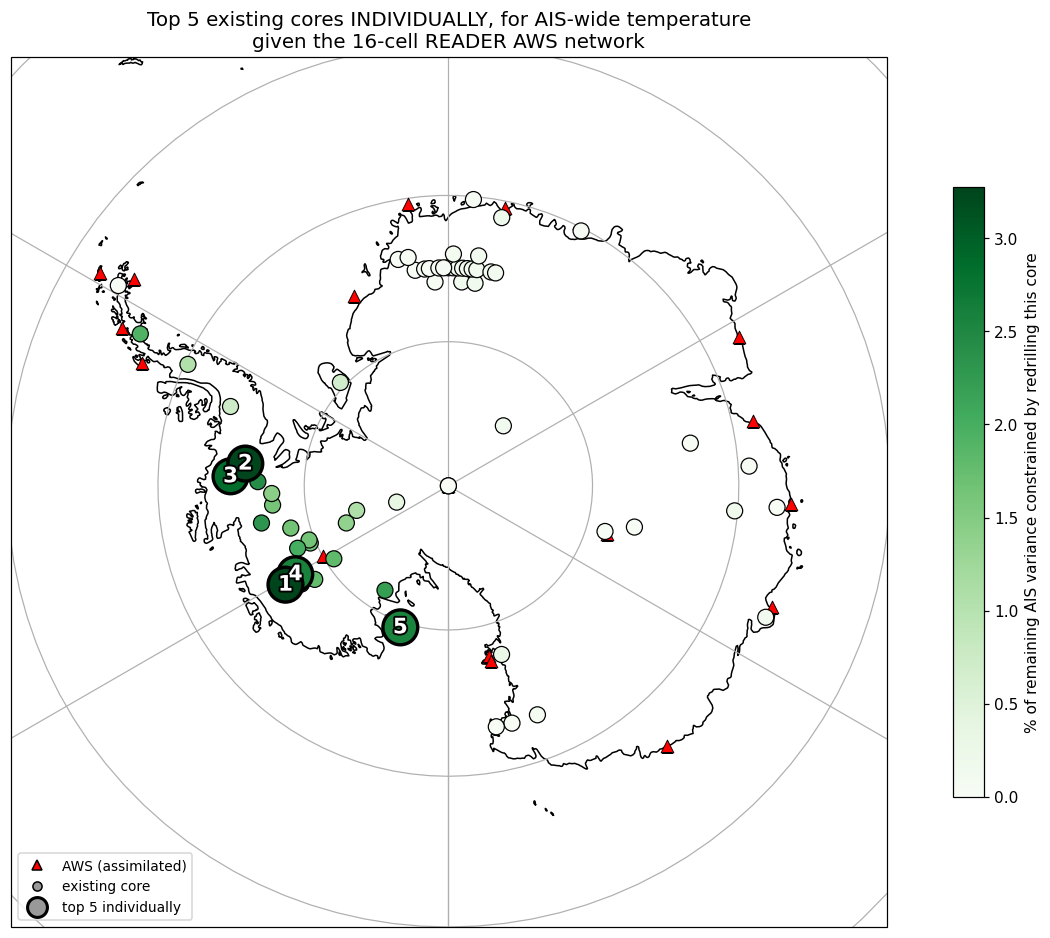

In [691]:
N_NEW = 5

# --- existing water-isotope core sites ---
cc = pd.read_csv(Path.home()/'DataFiles'/'WaterCoresCoords.csv', header=None,
                 names=['name', 'alt', 'lat', 'lon'])
cc['lat'] = cc.lat.astype(float)
cc['lon'] = np.mod(cc.lon.astype(float), 360.)
d = np.array([haversine_km(a, b, site_lat, site_lon) for a, b in zip(cc.lat, cc.lon)])
cc['site'] = d.argmin(1); cc['km'] = d.min(1)

CORE_SITES = sorted(set(cc.site))
core_mask  = np.zeros(N_POTENTIAL, bool); core_mask[CORE_SITES] = True
name_of = {}
for _, r in cc.iterrows():
    name_of.setdefault(int(r.site), r['name'])
print(f'{len(cc)} cores -> {len(CORE_SITES)} unique cells '
      f'(median offset {cc.km.median():.0f} km)')

# --- assimilate the AWS network, then evaluate every core ONCE ---
o = OptimalSensor(J, Ye[:N_POTENTIAL], R_ICE_CORE)
J0 = o.J0var
for i in AWS_SITES:
    o.assimilate(int(i), Rval=R_AWS_ASSIM)
v0 = o.metric_variance()
dv = np.where(np.isfinite(o.evaluate()), o.evaluate(), np.nan)
pct = 100 * dv / v0

# Each core's value ASSIMILATED ALONE. These are the five best INDIVIDUAL
# choices -- they are NOT additive, since they overlap with one another.
st_alone = np.argsort(np.where(core_mask, pct, -np.inf))[::-1][:N_NEW]

print(f'\nAIS metric variance {J0:.5f}; AWS network leaves {v0:.5f} '
      f'({100*(1-v0/J0):.1f}% constrained)')
print(pd.DataFrame({'rank': range(1, N_NEW+1),
                    'core': [name_of[int(s)] for s in st_alone], 'site': st_alone,
                    'lat': site_lat[st_alone], 'lon': site_lon[st_alone],
                    'accum': accum_rate[st_alone], 'R': R_ICE_CORE[st_alone],
                    'alone_pct': pct[st_alone]}).set_index('rank').round(2).to_string())
print(f'sum of the five: {pct[st_alone].sum():.2f}%  '
      f'(NOT what they would achieve together -- see the network cell)')

# --- map ---
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

CMAP = plt.cm.Greens
VMAX = float(np.nanmax(pct[CORE_SITES]))

SP, PL = ccrs.SouthPolarStereo(), ccrs.PlateCarree()
fig = plt.figure(figsize=(13, 12))
ax = plt.axes(projection=SP)
ax.set_extent([-180, 180, -90, -60], PL)
ax.gridlines(); ax.coastlines()

ax.scatter(aws_map.lon, aws_map.lat, marker='^', s=70, c='red',
           edgecolors='k', lw=.6, transform=PL, zorder=2)

other = [k for k in CORE_SITES if k not in set(st_alone)]
sc = ax.scatter(site_lon[other], site_lat[other], c=pct[other], s=110,
                cmap=CMAP, vmin=0, vmax=VMAX, edgecolors='k', lw=.8,
                transform=PL, zorder=3)

order = np.arange(N_NEW)[::-1]              # paint worst-first, rank 1 on top
ax.scatter(site_lon[st_alone][order], site_lat[st_alone][order],
           c=pct[st_alone][order], s=520, cmap=CMAP, vmin=0, vmax=VMAX,
           edgecolors='k', lw=2.2, transform=PL, zorder=4)

for r_, k in zip(range(N_NEW, 0, -1), st_alone[::-1]):
    ax.annotate(str(r_), (site_lon[k], site_lat[k]),
                xycoords=PL._as_mpl_transform(ax), ha='center', va='center',
                fontsize=14, fontweight='bold', color='w',
                zorder=5 + (N_NEW - r_) * 0.01,
                path_effects=[pe.withStroke(linewidth=2.5, foreground='k')])

cb = fig.colorbar(sc, ax=ax, shrink=.6, pad=.06)
cb.set_label('% of remaining AIS variance constrained by redrilling this core')
ax.legend(handles=[Line2D([], [], marker='^', ls='', c='red', mec='k',
                          label='AWS (assimilated)'),
                   Line2D([], [], marker='o', ls='', c='0.6', mec='k',
                          label='existing core'),
                   Line2D([], [], marker='o', ls='', c='0.6', mec='k', ms=13,
                          mew=2, label='top 5 individually')],
          loc='lower left', fontsize=9)
ax.set_title(f'Top {N_NEW} existing cores INDIVIDUALLY, for AIS-wide temperature\n'
             f'given the {len(AWS_SITES)}-cell READER AWS network', fontsize=13)
plt.show()


AIS metric variance 0.31829; AWS network leaves 0.01773 (94.4% constrained)
               core  site    lat     lon   accum     R  alone_pct  marginal_pct  cum_pct_remaining
rank                                                                                              
1               THW  4154 -76.81  238.75  298.86  2.60       3.28          3.28               3.28
2     Siple Station  4417 -75.86  276.25  362.24  2.14       3.26          2.71               5.99
3              RICE  3327 -79.63  198.75  144.67  5.37       2.55          1.85               7.84
4     Bruce Plateau  5778 -66.44  296.25  719.41  1.08       1.93          1.62               9.46
5      Siple Dome A  2761 -81.52  211.25  110.66  7.02       2.21          1.45              10.91

network total: 10.91% of remaining variance
overlap with the individual top 5: 3/5


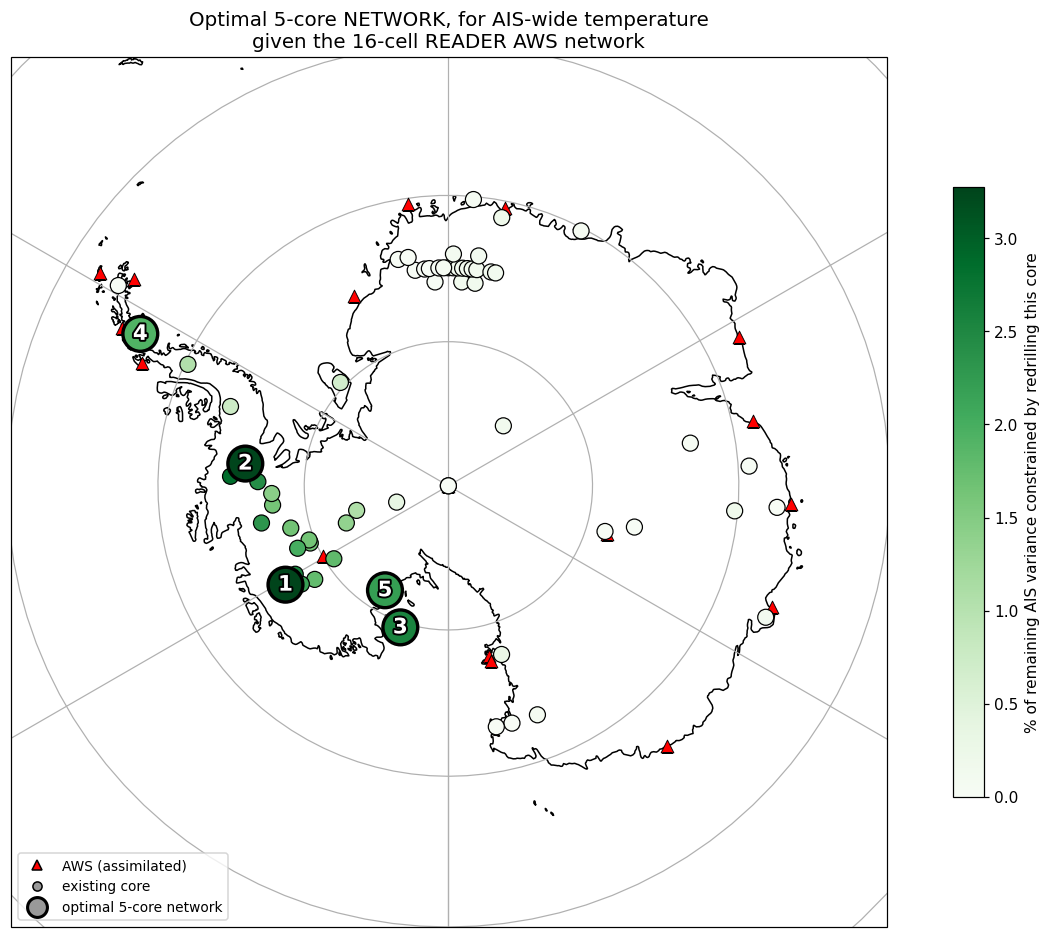

In [692]:
N_NEW = 5

# Greedy sequential: pick the best core, assimilate it, re-evaluate, repeat.
# Each site is credited only for what it adds beyond those already chosen, so
# this answers "which FIVE together" rather than "which five individually".
o2 = OptimalSensor(J, Ye[:N_POTENTIAL], R_ICE_CORE)
for i in AWS_SITES:
    o2.assimilate(int(i), Rval=R_AWS_ASSIM)
st_net, vr = o2.run(N_NEW, exclude=~core_mask, verbose=False)

marginal = -100 * np.diff(np.concatenate([[v0], vr])) / v0

print(f'AIS metric variance {J0:.5f}; AWS network leaves {v0:.5f} '
      f'({100*(1-v0/J0):.1f}% constrained)')
print(pd.DataFrame({'rank': range(1, N_NEW+1),
                    'core': [name_of[int(s)] for s in st_net], 'site': st_net,
                    'lat': site_lat[st_net], 'lon': site_lon[st_net],
                    'accum': accum_rate[st_net], 'R': R_ICE_CORE[st_net],
                    'alone_pct': pct[st_net],
                    'marginal_pct': marginal,
                    'cum_pct_remaining': 100*(1 - vr/v0)}).set_index('rank')
      .round(2).to_string())
print(f'\nnetwork total: {100*(1-vr[-1]/v0):.2f}% of remaining variance')
print(f'overlap with the individual top {N_NEW}: '
      f'{len(set(st_net) & set(st_alone))}/{N_NEW}')

# --- map (same colour scale as the individual cell, so the two are comparable) ---
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

CMAP = plt.cm.Greens
VMAX = float(np.nanmax(pct[CORE_SITES]))

SP, PL = ccrs.SouthPolarStereo(), ccrs.PlateCarree()
fig = plt.figure(figsize=(13, 12))
ax = plt.axes(projection=SP)
ax.set_extent([-180, 180, -90, -60], PL)
ax.gridlines(); ax.coastlines()

ax.scatter(aws_map.lon, aws_map.lat, marker='^', s=70, c='red',
           edgecolors='k', lw=.6, transform=PL, zorder=2)

other = [k for k in CORE_SITES if k not in set(st_net)]
sc = ax.scatter(site_lon[other], site_lat[other], c=pct[other], s=110,
                cmap=CMAP, vmin=0, vmax=VMAX, edgecolors='k', lw=.8,
                transform=PL, zorder=3)

order = np.arange(N_NEW)[::-1]
ax.scatter(site_lon[st_net][order], site_lat[st_net][order],
           c=pct[st_net][order], s=520, cmap=CMAP, vmin=0, vmax=VMAX,
           edgecolors='k', lw=2.2, transform=PL, zorder=4)

for r_, k in zip(range(N_NEW, 0, -1), st_net[::-1]):
    ax.annotate(str(r_), (site_lon[k], site_lat[k]),
                xycoords=PL._as_mpl_transform(ax), ha='center', va='center',
                fontsize=14, fontweight='bold', color='w',
                zorder=5 + (N_NEW - r_) * 0.01,
                path_effects=[pe.withStroke(linewidth=2.5, foreground='k')])

cb = fig.colorbar(sc, ax=ax, shrink=.6, pad=.06)
cb.set_label('% of remaining AIS variance constrained by redrilling this core')
ax.legend(handles=[Line2D([], [], marker='^', ls='', c='red', mec='k',
                          label='AWS (assimilated)'),
                   Line2D([], [], marker='o', ls='', c='0.6', mec='k',
                          label='existing core'),
                   Line2D([], [], marker='o', ls='', c='0.6', mec='k', ms=13,
                          mew=2, label='optimal 5-core network')],
          loc='lower left', fontsize=9)
ax.set_title(f'Optimal {N_NEW}-core NETWORK, for AIS-wide temperature\n'
             f'given the {len(AWS_SITES)}-cell READER AWS network', fontsize=13)
plt.show()


In [679]:
# The CCSM4 grid has no basin field, so sample the IMBIE basins and topography
# from the RACMO ANT11 mask at each site location (nearest neighbour on the
# sphere). Median distance is 4.3 km, so the lookup is effectively exact.
#
# NOTE: do not name anything _i / _ii / _iii / _ / __ here -- IPython reserves
# those for input/output history and overwrites them after every cell.
from scipy.spatial import cKDTree

assert site_lat.size == N_POTENTIAL, (
    f'site_lat has {site_lat.size} entries but N_POTENTIAL is {N_POTENTIAL} -- '
    're-run the site-coordinates cell, then this one.')

ANT11        = Path.home()/'DataFiles'/'ANT11_masks.nc'
GROUNDED_NPY = Path.home()/'DataFiles'/'ANT11_grounded_mask.npy'

ant11      = xr.open_dataset(ANT11)
ant11_ice  = ant11['Icesheet_Only'].values > 0.5
ant11_B    = ant11['Basins'].values[ant11_ice]
ant11_topo = ant11['Topography'].values[ant11_ice]
ant11_lat  = ant11['lat'].values[ant11_ice]
ant11_lon  = np.mod(ant11['lon'].values, 360.)[ant11_ice]
ant11_gr   = np.load(GROUNDED_NPY)[ant11_ice]

def to_xyz(la, lo):
    la, lo = np.radians(la), np.radians(lo)
    return np.stack([np.cos(la)*np.cos(lo), np.cos(la)*np.sin(lo), np.sin(la)], -1)

nn_dist, nn_idx = cKDTree(to_xyz(ant11_lat, ant11_lon)).query(
    to_xyz(site_lat, site_lon))
nn_km = 2*6371.0088*np.arcsin(np.clip(nn_dist/2, 0, 1))

site_basin          = ant11_B[nn_idx]
site_grounded_imbie = ant11_gr[nn_idx]
site_elev           = ant11_topo[nn_idx]      # <-- this is what was missing
too_far             = nn_km > 150

# IMBIE basins grouped by centroid geography. Verified areas on the native
# ANT11 grid: EAIS 10.13, WAIS 1.88, AP 0.31 M km^2.
REGIONS = {
    'EAIS': [2, 4, 5, 7, 9, 12, 13, 14, 15, 17],
    'WAIS': [1, 18, 20, 21, 23],
    'AP':   [24, 25, 27],
}
region_mask = {rn: (np.isin(site_basin, ids) & site_grounded_imbie & ~too_far)
               for rn, ids in REGIONS.items()}

wts = np.cos(np.deg2rad(site_lat))
print(f'nearest ANT11 cell: median {np.median(nn_km):.1f} km, max {nn_km.max():.0f} km '
      f'({too_far.sum()} site(s) >150 km excluded)')
for rn, rm_ in region_mask.items():
    print(f'  {rn:5s} {rm_.sum():5d} sites, '
          f'{100*wts[rm_].sum()/wts.sum():5.1f}% of cos-lat weight')
print(f'  unassigned: {N_POTENTIAL - sum(v.sum() for v in region_mask.values())} '
      f'(ice shelves and cells outside the basins)')
print(f'site elevation: {site_elev.min():.0f}-{site_elev.max():.0f} m, '
      f'median {np.median(site_elev):.0f} m')


nearest ANT11 cell: median 4.3 km, max 117 km (0 site(s) >150 km excluded)
  EAIS   4529 sites,  73.0% of cos-lat weight
  WAIS    698 sites,  13.7% of cos-lat weight
  AP       69 sites,   2.4% of cos-lat weight
  unassigned: 497 (ice shelves and cells outside the basins)
site elevation: 5-4072 m, median 2545 m


In [680]:
metrics = {rn: build_metric(Ye, mask=rm_) for rn, rm_ in region_mask.items()}
for rn, Jr in metrics.items():
    print(f'{rn:5s} mean {Jr.mean():7.2f} K   sd {Jr.std(ddof=1):.3f} K   '
          f'variance {unbias*((Jr-Jr.mean())**2).sum():.5f}')


EAIS  mean    0.00 K   sd 0.604 K   variance 0.36525
WAIS  mean   -0.00 K   sd 0.750 K   variance 0.56298
AP    mean    0.00 K   sd 0.859 K   variance 0.73845


In [689]:
def experiment_for(Jr, candidate_R):
    """Pre-assimilate the AWS network, then evaluate every site against Jr."""
    o = OptimalSensor(Jr, Ye[:N_POTENTIAL], candidate_R)
    J0 = o.J0var
    for i in AWS_SITES:
        o.assimilate(int(i), Rval=R_AWS_ASSIM)
    dv = o.evaluate()
    return J0, o.metric_variance(), np.where(np.isfinite(dv), dv, np.nan)

reg_res = {}
for rn in REGIONS:
    for lbl, cand in [('ICE CORE', R_ICE_CORE), ('AWS', R_AWS_ASSIM)]:
        J0, v0, dv = experiment_for(metrics[rn], cand)
        reg_res[(rn, lbl)] = (J0, v0, dv)
        k = int(np.nanargmax(dv))
        print(f'{rn:5s} {lbl:9s}  AWS net {100*(1-v0/J0):5.1f}%  |  '
              f'best {k:5d} ({site_lat[k]:7.2f}, {site_lon[k]:7.2f})  '
              f'accum {accum_rate[k]:7.1f}  ->  +{100*np.nanmax(dv)/v0:5.2f}% of remaining')


EAIS  ICE CORE   AWS net  95.3%  |  best  5180 ( -72.09,  263.75)  accum   623.2  ->  + 2.64% of remaining
EAIS  AWS        AWS net  95.3%  |  best  2624 ( -81.52,   40.00)  accum    32.4  ->  +30.24% of remaining
WAIS  ICE CORE   AWS net  89.6%  |  best  4826 ( -73.98,  278.75)  accum   611.1  ->  +16.73% of remaining
WAIS  AWS        AWS net  89.6%  |  best  4402 ( -75.86,  257.50)  accum   614.9  ->  +47.28% of remaining
AP    ICE CORE   AWS net  82.8%  |  best  5018 ( -73.04,  293.75)  accum   567.6  ->  +18.39% of remaining
AP    AWS        AWS net  82.8%  |  best  5019 ( -73.04,  295.00)  accum   516.7  ->  +80.14% of remaining


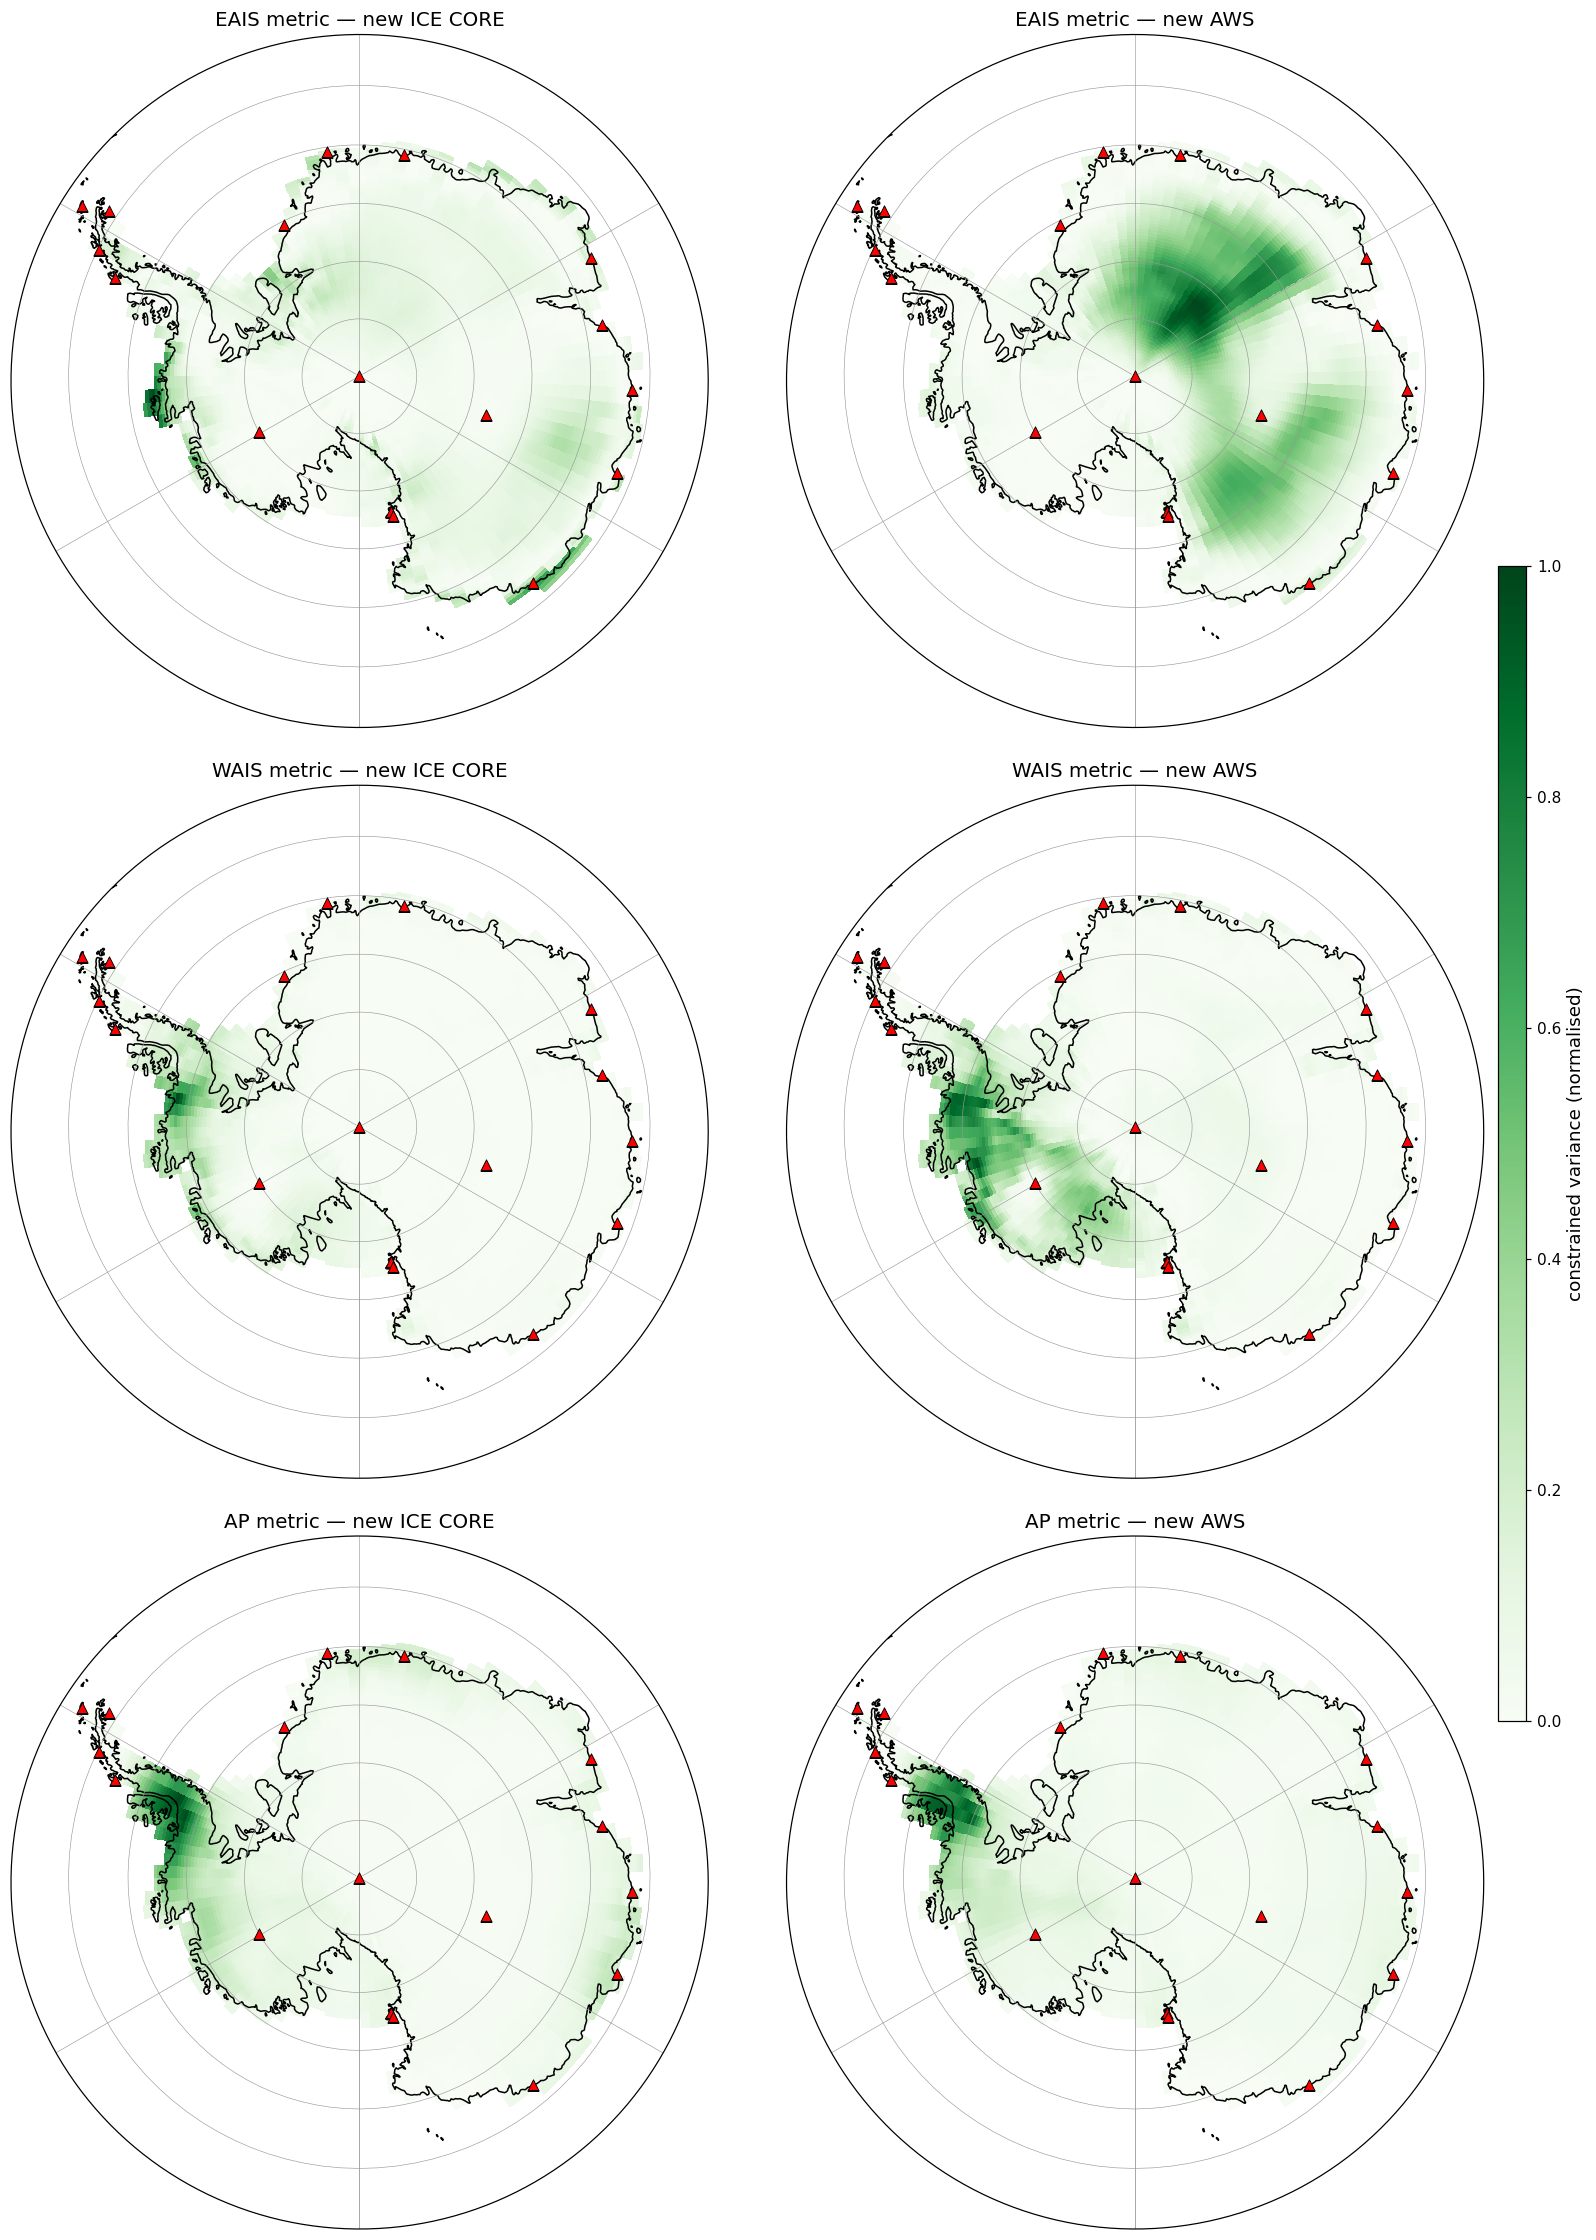

In [682]:
SP, PL = ccrs.SouthPolarStereo(), ccrs.PlateCarree()
fig = plt.figure(figsize=(15, 21))

for r, rn in enumerate(REGIONS):
    for c, lbl in enumerate(['ICE CORE', 'AWS']):
        J0, v0, dv = reg_res[(rn, lbl)]
        ax = fig.add_axes([0.02 + c*0.47, 0.68 - r*0.325, 0.44, 0.30],
                          projection=SP)
        ax.set_extent([-180, 180, -90, -60], PL)
        th = np.linspace(0, 2*np.pi, 200)
        ax.set_boundary(mpath.Path(np.stack([np.cos(th), np.sin(th)], 1)*.5+.5),
                        transform=ax.transAxes)
        ax.gridlines(linewidth=.4, color='0.6')

        lm, am, g = interp_field(dv/np.nanmax(dv))
        pm = ax.pcolormesh(lm, am, g, transform=PL, cmap=plt.cm.Greens,
                           vmin=0, vmax=1, zorder=0)

        ax.scatter(aws_map.lon, aws_map.lat, marker='^', s=55, c='red',
                   edgecolors='k', lw=.6, transform=PL, zorder=3)
        ax.coastlines()
        ax.set_title(f'{rn} metric — new {lbl}', fontsize=13)

cax = fig.add_axes([0.93, 0.25, 0.017, 0.5])
cb = fig.colorbar(pm, cax=cax)
cb.set_label('constrained variance (normalised)', fontsize=12)
plt.show()


In [683]:
# --- PAGES Ant-2K regions (Stenni et al. 2017), port of regions_Ant2K.m ---
# site_elev now comes from region cell A, so this cell no longer computes it.
PLATEAU_ALTI, PENI, WED, B_AI = 2000.0, -74.0, 330.0, 67.0

_VIC = """-85 150
-84 150
-83 149
-82 148
-81 147
-80 149
-79 150
-78 150
-77 150
-76 155
-75 160
-74 160
-73 160
-72 160
-71 160
-70 160
-69 160
-68 160
-67 160
-66 160
-65 160
-64 160
-63 160"""
vic_tab = np.array([[float(x) for x in l.split()] for l in _VIC.strip().splitlines()])
vic_ord = np.argsort(vic_tab[:, 0])
lats_v, vlim = vic_tab[vic_ord, 0], vic_tab[vic_ord, 1]

def regions_ant2k(lat, lon, elevi, edml_zero=False):
    """Rules applied in order, later ones overwriting -- as in the MATLAB.
    edml_zero=True reproduces the original's region-0 bug; False is the fix."""
    lat = np.asarray(lat, float); lon = np.asarray(lon, float)
    elevi = np.asarray(elevi, float); sh = lat.shape
    vlat = lat.ravel(); vlon = np.mod(lon.ravel(), 360.); ve = elevi.ravel()
    reg = np.full(vlat.shape, np.nan)
    vll = np.interp(vlat, lats_v, vlim, left=np.nan, right=np.nan)
    with np.errstate(invalid='ignore'):
        reg[(vlon < 145) & (ve > PLATEAU_ALTI)] = 1
        reg[(vlon >= 145) & (vlon < 190) & (ve >= 0) & (vlon < vll)] = 1
        reg[(vlon >= 145) & (vlon < 350) & (vlat < -84) & (ve >= 0)] = 1
        f = 0. if edml_zero else 1.
        reg[(vlon < 30) & (ve > PLATEAU_ALTI)] = f
        reg[(vlon >= 300) & (ve > PLATEAU_ALTI)] = f
        reg[(vlon > WED) & (ve < PLATEAU_ALTI) & (vlat > -76) & (ve >= 0)] = 7
        reg[(vlon > 0) & (vlon < B_AI) & (ve < PLATEAU_ALTI)] = 7
        reg[(vlon > WED) & (ve < PLATEAU_ALTI) & (vlat < -75) & (ve >= 0)] = 3
        reg[(vlon >= 300) & (vlon < WED) & (ve < PLATEAU_ALTI)] = 3
        reg[(vlon >= B_AI) & (vlon < 145) & (ve < PLATEAU_ALTI)] = 2
        reg[(vlon >= 145) & (vlon < 160) & (ve >= 0) & (vlon < vll)
            & (ve < PLATEAU_ALTI) & (vlat > -72)] = 2
        reg[(vlon >= 145) & (vlon < 190) & (ve >= 0) & (vlat < -74) & (vlon > vll)] = 6
        reg[(vlon >= 160) & (vlon < 190) & (ve >= 0) & (vlon > vll)] = 6
        reg[(vlon >= 190) & (vlon < 280) & (vlat > -85) & (ve >= 0)] = 5
        reg[(vlon >= 280) & (vlon < 300) & (vlat > -85) & (vlat < PENI+.5) & (ve >= 0)] = 5
        reg[(vlon >= 280) & (vlon < 305) & (vlat > PENI) & (ve >= 0)] = 4
    return reg.reshape(sh)

P2K_NAMES = {1: 'East Antarctic Plateau', 2: 'Wilkes Land Coast',
             3: 'Weddell Sea Coast', 4: 'Antarctic Peninsula', 5: 'WAIS',
             6: 'Victoria Land / Ross Sea', 7: 'Dronning Maud Land Coast'}

site_region = regions_ant2k(site_lat, site_lon, site_elev, edml_zero=False)
p2k_mask = {v: ((site_region == v) & site_grounded_imbie & ~too_far)
            for v in range(1, 8)}

print(f'{"region":32s} {"sites":>6s} {"weight":>8s}')
for v, nm in P2K_NAMES.items():
    mk_ = p2k_mask[v]
    print(f'{v} {nm:30s} {mk_.sum():6d} {100*wts[mk_].sum()/wts.sum():7.1f}%')
print(f'unassigned or ungrounded: '
      f'{int((~np.isin(site_region, list(range(1,8))) | ~site_grounded_imbie).sum())}')


region                            sites   weight
1 East Antarctic Plateau           3677    52.4%
2 Wilkes Land Coast                 183     6.9%
3 Weddell Sea Coast                 276     4.4%
4 Antarctic Peninsula                70     2.4%
5 WAIS                              771    14.4%
6 Victoria Land / Ross Sea          146     2.8%
7 Dronning Maud Land Coast          157     5.4%
unassigned or ungrounded: 513


In [684]:
p2k_metrics = {v: build_metric(Ye, mask=p2k_mask[v]) for v in range(1, 8)}

p2k_res = {}
print(f'{"region":32s} {"sd":>6s} {"AWSnet":>7s} {"core+%":>7s} {"aws+%":>7s}  best core site')
for v, nm in P2K_NAMES.items():
    Jr = p2k_metrics[v]
    for lbl, cand in [('ICE CORE', R_ICE_CORE), ('AWS', R_AWS_ASSIM)]:
        p2k_res[(v, lbl)] = experiment_for(Jr, cand)
    J0, v0, dvc = p2k_res[(v, 'ICE CORE')]
    _,  _,  dva = p2k_res[(v, 'AWS')]
    k = int(np.nanargmax(dvc))
    print(f'{v} {nm:30s} {Jr.std(ddof=1):6.3f} {100*(1-v0/J0):6.1f}% '
          f'{100*np.nanmax(dvc)/v0:6.2f}% {100*np.nanmax(dva)/v0:6.2f}%  '
          f'({site_lat[k]:7.2f}, {site_lon[k]:7.2f}) A={accum_rate[k]:.0f}')


region                               sd  AWSnet  core+%   aws+%  best core site
1 East Antarctic Plateau          0.651   94.4%   3.02%  37.75%  ( -66.44,  136.25) A=634
2 Wilkes Land Coast               0.682   95.1%   6.67%  33.96%  ( -68.32,  145.00) A=427
3 Weddell Sea Coast               0.777   64.5%  14.28%  92.21%  ( -78.69,  320.00) A=185
4 Antarctic Peninsula             0.859   82.5%  18.33%  80.36%  ( -73.04,  293.75) A=568
5 WAIS                            0.741   89.5%  16.16%  45.58%  ( -73.98,  278.75) A=611
6 Victoria Land / Ross Sea        0.701   81.8%   7.67%  59.03%  ( -69.27,  152.50) A=403
7 Dronning Maud Land Coast        0.565   90.6%   7.83%  67.81%  ( -70.21,    3.75) A=435


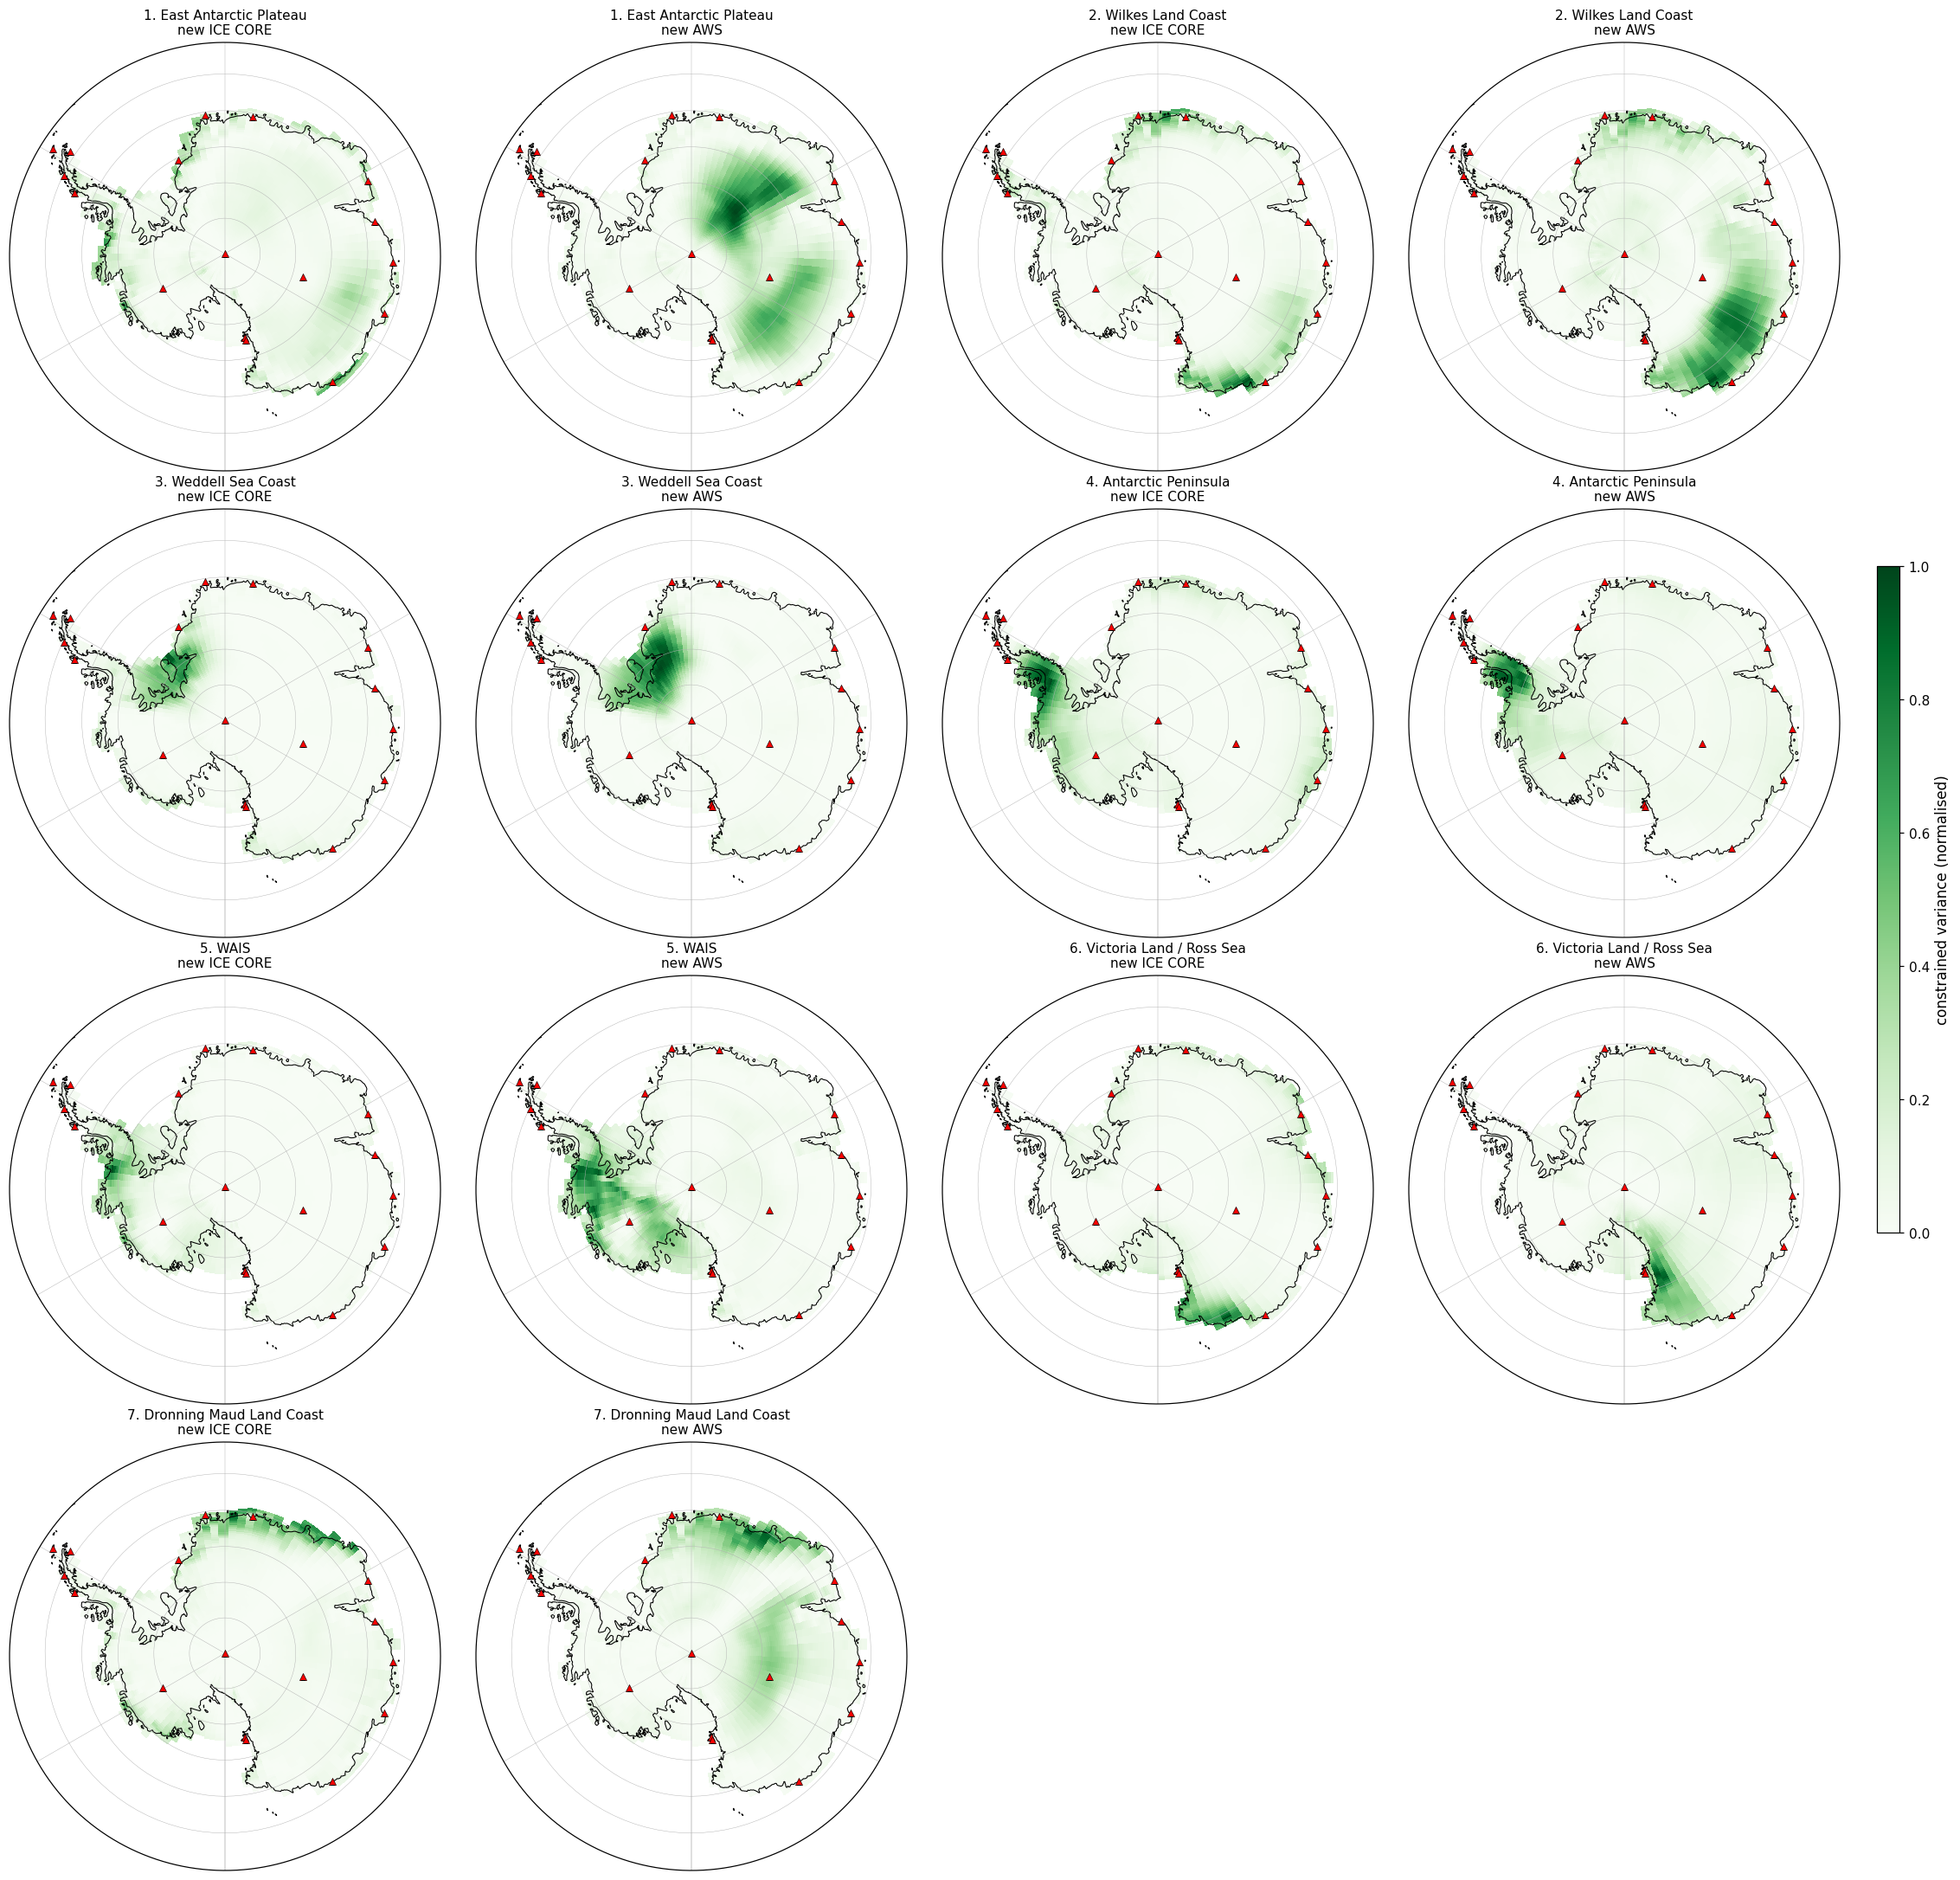

In [685]:
SP, PL = ccrs.SouthPolarStereo(), ccrs.PlateCarree()
fig = plt.figure(figsize=(20, 20))

for idx, v in enumerate(range(1, 8)):
    for c, lbl in enumerate(['ICE CORE', 'AWS']):
        p = idx*2 + c
        r_, cc = divmod(p, 4)
        ax = fig.add_axes([0.01 + cc*0.245, 0.75 - r_*0.245, 0.235, 0.225],
                          projection=SP)
        ax.set_extent([-180, 180, -90, -60], PL)
        th = np.linspace(0, 2*np.pi, 200)
        ax.set_boundary(mpath.Path(np.stack([np.cos(th), np.sin(th)], 1)*.5+.5),
                        transform=ax.transAxes)
        ax.gridlines(linewidth=.3, color='0.7')

        J0, v0, dv = p2k_res[(v, lbl)]
        lm, am, g = interp_field(dv/np.nanmax(dv))
        pm = ax.pcolormesh(lm, am, g, transform=PL, cmap=plt.cm.Greens,
                           vmin=0, vmax=1, zorder=0)
        ax.scatter(aws_map.lon, aws_map.lat, marker='^', s=28, c='red',
                   edgecolors='k', lw=.4, transform=PL, zorder=3)
        ax.coastlines(linewidth=.7)
        ax.set_title(f'{v}. {P2K_NAMES[v]}\nnew {lbl}', fontsize=10)

cax = fig.add_axes([0.995, 0.35, 0.012, 0.35])
cb = fig.colorbar(pm, cax=cax)
cb.set_label('constrained variance (normalised)', fontsize=11)
plt.show()
